<a href="https://colab.research.google.com/github/viktorbrojs-sys/BH_DS_Pro/blob/main/HW2/AutoEncoder_latent_text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch

In [11]:
import random
import time
import os

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

from torch.utils.data import DataLoader, TensorDataset

import nltk
from nltk.corpus import reuters

In [12]:
# Загрузка текстовых данных

# убеждаемся, что корпус доступен
nltk.download('reuters')

start_time = time.time()

# получаем список всех документов
all_fileids = reuters.fileids()

# случайно выбираем 1000 документов (не по порядку)
random.seed(42)
sample_fileids = random.sample(all_fileids, 1000)

# собираем тексты
texts = [" ".join(reuters.words(fid)) for fid in sample_fileids]

print(f"\nЗагружено текстов: {len(texts)}")
print(f"Время подготовки данных: {time.time() - start_time:.2f} сек\n")

# вывод первых 5 текстов для понимания структуры
for i, text in enumerate(texts[:5], 1):
    print(f"--- Текст {i} ---\n{text[:200]}...\n")


[nltk_data] Downloading package reuters to /root/nltk_data...
[nltk_data]   Package reuters is already up-to-date!



Загружено текстов: 1000
Время подготовки данных: 0.21 сек

--- Текст 1 ---
PAN ATLANTIC RE INC & lt ; PNRE > 4TH QTR NET Oper shr 15 cts vs 1 . 07 dlrs Oper net 372 , 000 vs 2 , 601 , 000 Year Oper shr 80 cts vs 61 cts Oper net 1 , 952 , 000 vs 1 , 491 , 000 NOTE : Net exclu...

--- Текст 2 ---
OECD SEES GERMAN GROWTH HIT BY LOW DOMESTIC DEMAND West German economic growth will slow to 1 . 5 pct this year from 2 . 4 pct in 1986 due to weak domestic demand and tougher competition from abroad ,...

--- Текст 3 ---
YUGOSLAVIA TO TENDER FOR 100 , 000 TONNES WHEAT Yugoslavia will tender April 14 for 100 , 000 tonnes of wheat , the U . S . Agriculture Department ' s Counselor in Belgrade said in a field report . Th...

--- Текст 4 ---
TRANSDUCER SYSTEMS INC YEAR Shr profit 12 cts vs loss 49 cts Net profit 117 , 000 vs loss 506 , 000 Revs 1 . 1 mln vs 1 . 2 mln Year Shr profit seven cts vs loss 89 cts Net profit 66 , 000 vs loss 921...

--- Текст 5 ---
SWISS MONEY MARKET PAPER YIELDS 3 . 286 

In [13]:
# Преобразование в TF-IDF

# создаём векторизатор
vectorizer = TfidfVectorizer(
    lowercase=True,         # приводим к нижнему регистру
    stop_words='english',   # удаляем стоп-слова
    max_features=1000,      # ограничиваем размер словаря
    min_df=3,               # слово должно встретиться минимум в 3 документах
    max_df=0.8              # игнорируем слишком частые слова
)

# получаем разреженную матрицу
X = vectorizer.fit_transform(texts)

print(f"\nTF-IDF размерность: {X.shape}")

# переводим в плотный формат (для подачи в нейросеть)
X = X.toarray()


TF-IDF размерность: (1000, 1000)


In [14]:
# Нормализация данных

# важно для стабильного обучения нейросети
scaler = StandardScaler()
X = scaler.fit_transform(X)

# переводим в torch tensor
X = torch.tensor(X, dtype=torch.float32)

input_dim = X.shape[1]

In [15]:
# DataLoader (батчи)

batch_size = 32

dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [16]:
# Определение автоэнкодера

class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()

        # Энкодер: сжимает вход в компактное представление
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

        # Декодер: восстанавливает исходные данные
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)             # сжатие
        x_recon = self.decoder(z)       # восстановление
        return x_recon

In [23]:
# Функция обучения модели

def train_model(latent_dim):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = Autoencoder(input_dim, latent_dim).to(device)

    criterion = nn.MSELoss()                                        # функция потерь
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    epochs = 200
    losses = []

    train_start = time.time()

    for epoch in range(epochs):
        epoch_loss = 0

        for batch in dataloader:
            batch_x = batch[0].to(device)

            optimizer.zero_grad()

            # прямой проход
            output = model(batch_x)

            # считаем ошибку реконструкции
            loss = criterion(output, batch_x)

            # обратное распространение
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        losses.append(avg_loss)

        print(f"Эпоха {epoch+1}/{epochs}, loss: {avg_loss:.6f}")

    print(f"\nВремя обучения (latent_dim={latent_dim}): {time.time() - train_start:.2f} сек\n")

    return model, losses

In [24]:
# Обучение моделей

# малое скрытое пространство
model_5, loss_5 = train_model(latent_dim=5)

# для сравнения
model_50, loss_50 = train_model(latent_dim=50)

Эпоха 1/200, loss: 0.998466
Эпоха 2/200, loss: 0.978317
Эпоха 3/200, loss: 0.959317
Эпоха 4/200, loss: 0.941073
Эпоха 5/200, loss: 0.927999
Эпоха 6/200, loss: 0.907801
Эпоха 7/200, loss: 0.891454
Эпоха 8/200, loss: 0.881373
Эпоха 9/200, loss: 0.865792
Эпоха 10/200, loss: 0.849607
Эпоха 11/200, loss: 0.845010
Эпоха 12/200, loss: 0.836063
Эпоха 13/200, loss: 0.818463
Эпоха 14/200, loss: 0.818725
Эпоха 15/200, loss: 0.802515
Эпоха 16/200, loss: 0.790154
Эпоха 17/200, loss: 0.788258
Эпоха 18/200, loss: 0.771892
Эпоха 19/200, loss: 0.766775
Эпоха 20/200, loss: 0.766955
Эпоха 21/200, loss: 0.753974
Эпоха 22/200, loss: 0.748199
Эпоха 23/200, loss: 0.735853
Эпоха 24/200, loss: 0.725856
Эпоха 25/200, loss: 0.717511
Эпоха 26/200, loss: 0.709063
Эпоха 27/200, loss: 0.706248
Эпоха 28/200, loss: 0.698408
Эпоха 29/200, loss: 0.700002
Эпоха 30/200, loss: 0.690763
Эпоха 31/200, loss: 0.684610
Эпоха 32/200, loss: 0.676098
Эпоха 33/200, loss: 0.668633
Эпоха 34/200, loss: 0.660380
Эпоха 35/200, loss: 0.6

In [25]:
# Получение латентных векторов

with torch.no_grad():
    X_device = X.to(next(model_5.parameters()).device)

    latent_vectors_5 = model_5.encoder(X_device).cpu().numpy()
    latent_vectors_50 = model_50.encoder(X_device).cpu().numpy()

print("\nПервые 5 латентных векторов (dim=5):")
for i, vec in enumerate(latent_vectors_5[:5]):
    print(f"{i}: {vec}")


Первые 5 латентных векторов (dim=5):
0: [-13.316681    4.0539484   2.1900802  -3.0929053 -11.468087 ]
1: [ 22.80913  -29.37362    8.907692   3.399156  17.66619 ]
2: [-0.9605669  1.2338631 -8.073627   0.5781877 14.1200695]
3: [-9.297525   1.941315   1.6847022 -0.5117718 -3.9750066]
4: [ 9.26993   17.905035   4.80656    3.8357837 -4.3485327]


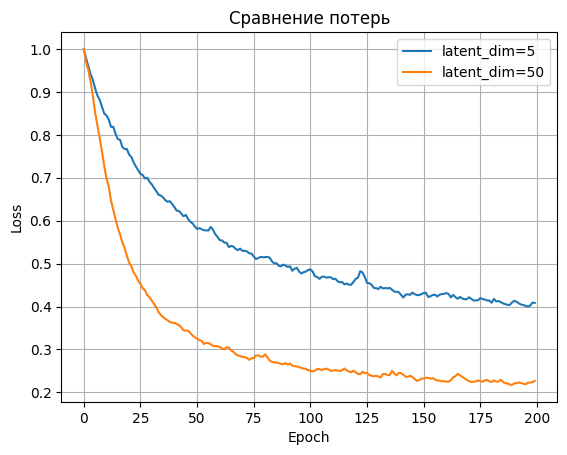

In [26]:
# Визуализация функции потерь

os.makedirs("results", exist_ok=True)

plt.figure()
plt.plot(loss_5, label="latent_dim=5")
plt.plot(loss_50, label="latent_dim=50")

plt.legend()
plt.title("Cравнение потерь")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

plt.savefig("results/loss_plot.png")
plt.show()

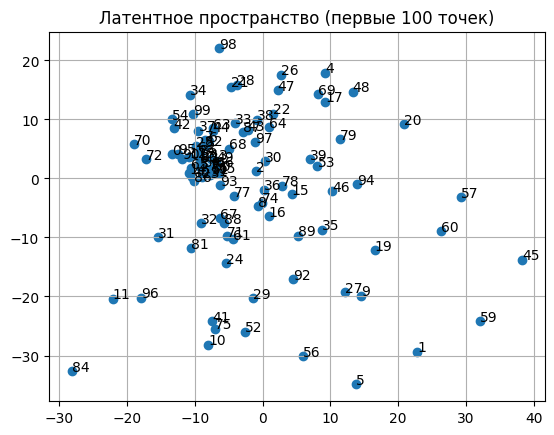

In [27]:
# Визуализация латентного пространства (dim=5 -> первые 2 координаты)

sample_size = 100

plt.figure()

plt.scatter(
    latent_vectors_5[:sample_size, 0],
    latent_vectors_5[:sample_size, 1]
)

# подписи точек (для наглядности)
for i in range(sample_size):
    plt.annotate(str(i), (
        latent_vectors_5[i, 0],
        latent_vectors_5[i, 1]
    ))

plt.title(f"Латентное пространство (первые {sample_size} точек)")
plt.grid()

plt.savefig("results/latent_space.png")
plt.show()